<a href="https://colab.research.google.com/github/Rihab-KHADIL/S12-03-2026RK/blob/main/ZinebHnouda_RihabKhadil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge

# ── Classification (ex: iris) ──────────────────────────────────────────────
iris = datasets.load_iris()           # 150 x 4,  3 classes
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify valide ici
)

model_clf = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", LogisticRegression())     # remplace MonModele()
])
model_clf.fit(X_tr, y_tr)
print("Accuracy iris :", model_clf.score(X_te, y_te))

# ── Autres datasets de classification ─────────────────────────────────────
breast = datasets.load_breast_cancer()  # 569 x 30, binaire
wine   = datasets.load_wine()           # 178 x 13, 3 classes
digits = datasets.load_digits()         # 1797 x 64, 10 classes

# ── Régression (ex: diabetes) ──────────────────────────────────────────────
diabetes = datasets.load_diabetes()     # 442 x 10, régression
X_r, y_r = diabetes.data, diabetes.target

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
    # pas de stratify=y : y est continu, pas des classes discrètes
)

model_reg = Pipeline([
    ("sc",  StandardScaler()),
    ("reg", Ridge())                  # estimateur de régression
])
model_reg.fit(X_tr_r, y_tr_r)
print("R² diabetes :", model_reg.score(X_te_r, y_te_r))

# ── California Housing (régression, fetch externe) ─────────────────────────
california = datasets.fetch_california_housing()  # 20640 x 8, prix
X_c, y_c = california.data, california.target

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
    # pas de stratify=y ici non plus
)

Accuracy iris : 0.9333333333333333
R² diabetes : 0.45414652070698225


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
X, y = datasets.load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Pipeline ───────────────────────────────────────────────────────────────
lr = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,   # augmenter si ConvergenceWarning
        C=1.0,           # inverse régularisation (grand = moins régularisé)
        random_state=42
    ))
])

lr.fit(X_train, y_train)

pred  = lr.predict(X_test)
proba = lr.predict_proba(X_test)    # probabilités par classe

# Coefficients : importance des features
coefs = lr["lr"].coef_              # (n_classes, n_features)
print("Prédictions   :", pred)
print("Forme probas  :", proba.shape)
print("Forme coefs   :", coefs.shape)

Prédictions   : [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Forme probas  : (30, 3)
Forme coefs   : (3, 4)


Importances : [0.         0.01873775 0.02016329 0.02086548 0.         0.
 0.40807303 0.         0.         0.40018907 0.         0.02098628
 0.11098512]


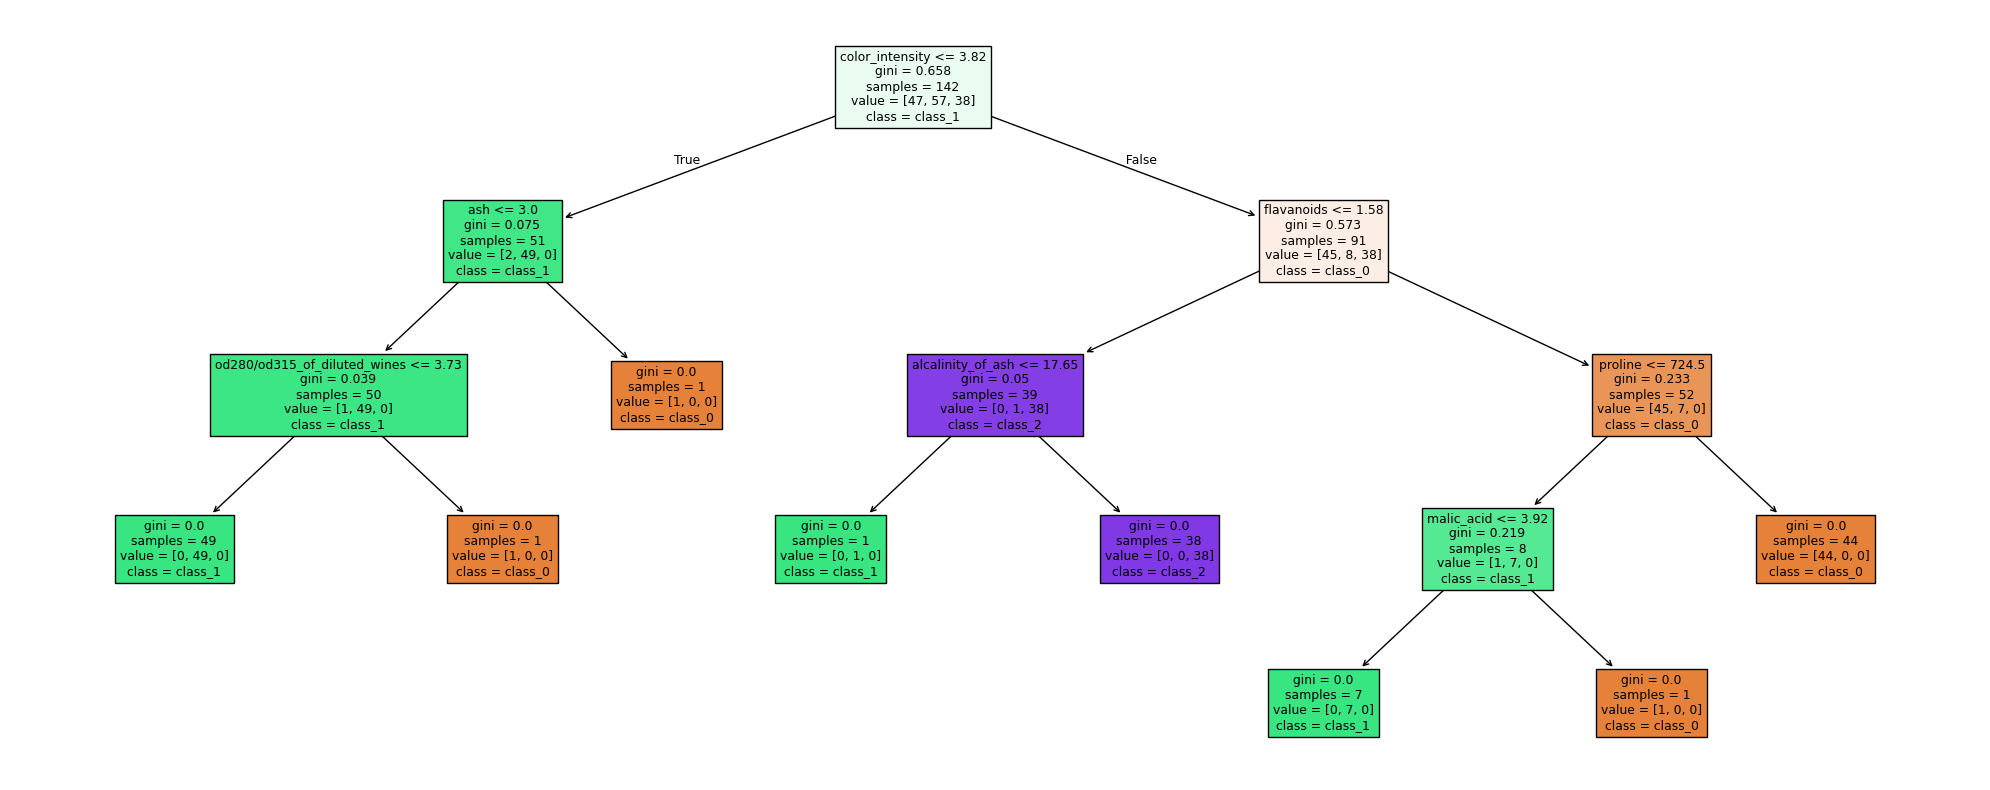

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
wine = datasets.load_wine()
X, y = wine.data, wine.target

X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=4,          # évite l'overfitting
    min_samples_split=5,  # nœud non divisé si < 5 points
    random_state=42
)
dt.fit(X_wine_tr, y_wine_tr)

importances = dt.feature_importances_  # importance de chaque feature (Gini)
print("Importances :", importances)

# ── Visualisation de l'arbre ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=wine.feature_names,
          class_names=wine.target_names, filled=True, ax=ax)
plt.tight_layout()
plt.show()

Importances : [0.11634851 0.01499973 0.43146641 0.43718536]


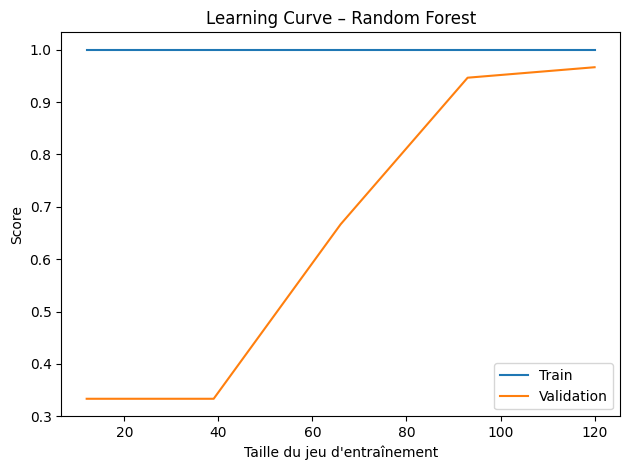

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve, train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par nœud
    random_state=42, n_jobs=-1
)
rf.fit(X_iris_tr, y_iris_tr)

# Feature importances (réduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_
print("Importances :", importances)

# ── Diagnostiquer l'overfitting ────────────────────────────────────────────
train_sz, train_sc, test_sc = learning_curve(rf, X, y, cv=5)

plt.plot(train_sz, train_sc.mean(axis=1), label="Train")
plt.plot(train_sz, test_sc.mean(axis=1),  label="Validation")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("Score")
plt.title("Learning Curve – Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

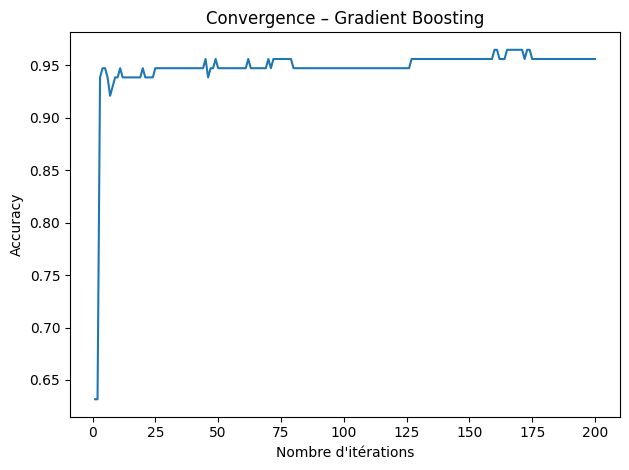

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
breast = datasets.load_breast_cancer()
X, y = breast.data, breast.target

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres séquentiels
    learning_rate=0.1,  # eta : petit -> meilleure généralisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)
gb.fit(X_bc_tr, y_bc_tr)

proba = gb.predict_proba(X_bc_te)[:, 1]  # probabilité classe positive

# ── Convergence : accuracy par itération ──────────────────────────────────
staged = [accuracy_score(y_bc_te, p) for p in gb.staged_predict(X_bc_te)]

plt.plot(range(1, len(staged) + 1), staged)
plt.xlabel("Nombre d'itérations")
plt.ylabel("Accuracy")
plt.title("Convergence – Gradient Boosting")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE pour SVM
    ("svm", SVC(
        kernel="rbf",      # gaussien : polyvalent
        C=1.0,             # pénalité d'erreur
        gamma="scale",     # adaptatif : 1/(p * Var(X))
        probability=True   # pour predict_proba (plus lent)
    ))
])

svm.fit(X_tr, y_tr)
pred  = svm.predict(X_te)
proba = svm.predict_proba(X_te)

print("Accuracy :", svm.score(X_te, y_te))

Accuracy : 0.9666666666666667


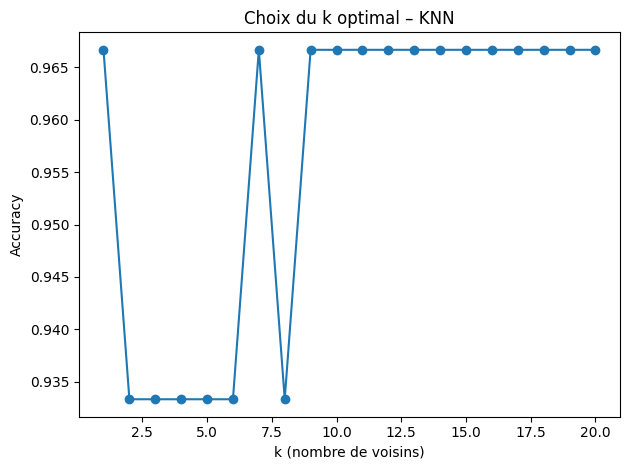

Meilleur k : 1 | Accuracy : 0.9667


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Trouver le k optimal ───────────────────────────────────────────────────
scores = []
for k in range(1, 21):
    knn = Pipeline([("sc",  StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    scores.append(acc)

# ── Visualisation ──────────────────────────────────────────────────────────
plt.plot(range(1, 21), scores, marker="o")
plt.xlabel("k (nombre de voisins)")
plt.ylabel("Accuracy")
plt.title("Choix du k optimal – KNN")
plt.tight_layout()
plt.show()

print("Meilleur k :", scores.index(max(scores)) + 1,
      "| Accuracy :", round(max(scores), 4))

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
gnb = GaussianNB()    # pas de normalisation nécessaire
gnb.fit(X_tr, y_tr)

proba = gnb.predict_proba(X_te)   # probabilités postérieures calibrées
print("Accuracy  :", gnb.score(X_te, y_te))
print("Moyennes  :\n", gnb.theta_)  # (n_classes, n_features) : moyennes par classe
print("Variances :\n", gnb.var_)    # (n_classes, n_features) : variances par classe

Accuracy  : 0.9666666666666667
Moyennes  :
 [[4.985  3.415  1.4775 0.255 ]
 [5.93   2.75   4.2525 1.32  ]
 [6.61   2.98   5.58   2.04  ]]
Variances :
 [[0.092775   0.155275   0.02524375 0.012975  ]
 [0.2216     0.093      0.19149375 0.0341    ]
 [0.4574     0.1221     0.3236     0.0704    ]]


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


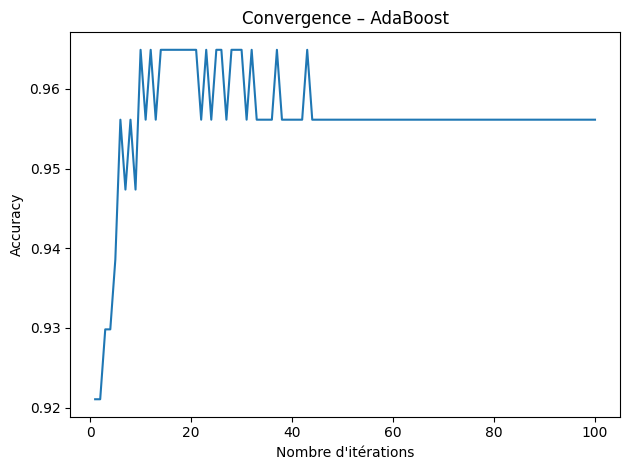

Meilleure accuracy : 0.9649 | itération : 10


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
breast = datasets.load_breast_cancer()
X, y = breast.data, breast.target

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
ada = AdaBoostClassifier(
    n_estimators=100, learning_rate=0.5,
    algorithm="SAMME", random_state=42
)
ada.fit(X_bc_tr, y_bc_tr)

# ── Évolution de l'accuracy par itération ─────────────────────────────────
staged_acc = [accuracy_score(y_bc_te, p) for p in ada.staged_predict(X_bc_te)]

plt.plot(range(1, len(staged_acc) + 1), staged_acc)
plt.xlabel("Nombre d'itérations")
plt.ylabel("Accuracy")
plt.title("Convergence – AdaBoost")
plt.tight_layout()
plt.show()

print("Meilleure accuracy :", round(max(staged_acc), 4),
      "| itération :", staged_acc.index(max(staged_acc)) + 1)

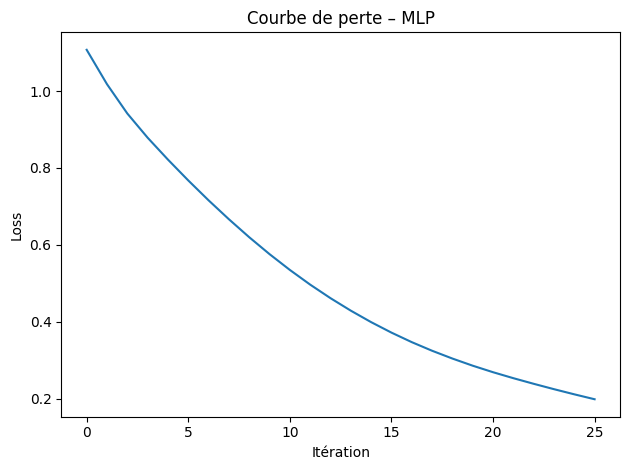

Accuracy : 0.8333333333333334


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
mlp = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 3 couches cachées
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,   # arrêt si val ne s'améliore plus
        validation_fraction=0.1,
        random_state=42
    ))
])

mlp.fit(X_tr, y_tr)  # fit() AVANT d'accéder à loss_curve_

# ── Courbe de perte ────────────────────────────────────────────────────────
loss_curve = mlp["mlp"].loss_curve_   # perte par itération

plt.plot(loss_curve)
plt.xlabel("Itération")
plt.ylabel("Loss")
plt.title("Courbe de perte – MLP")
plt.tight_layout()
plt.show()

print("Accuracy :", mlp.score(X_te, y_te))

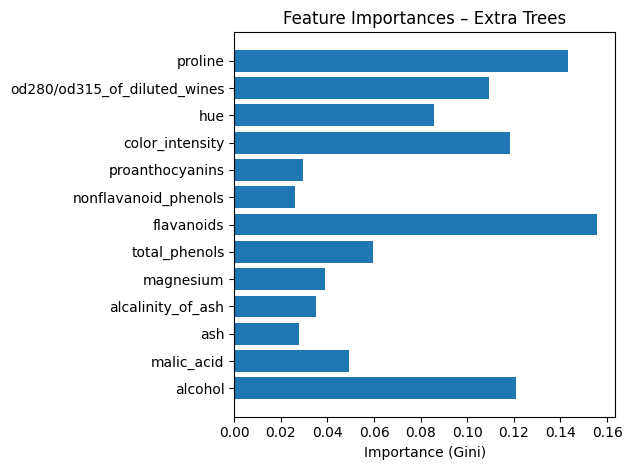

Accuracy : 1.0


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
wine = datasets.load_wine()
X, y = wine.data, wine.target

X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_wine_tr, y_wine_tr)

importances = et.feature_importances_

# ── Visualisation des importances ──────────────────────────────────────────
plt.barh(wine.feature_names, importances)
plt.xlabel("Importance (Gini)")
plt.title("Feature Importances – Extra Trees")
plt.tight_layout()
plt.show()

print("Accuracy :", et.score(X_wine_te, y_wine_te))

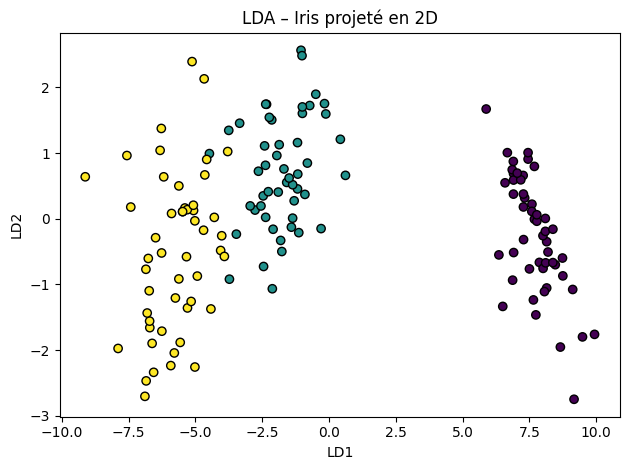

Accuracy : 1.0


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

# ── Réduction de dimension (ex: Iris 4D -> 2D) ────────────────────────────
X_2d = lda.transform(X)   # projection sur les axes discriminants

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="viridis", edgecolors="k")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA – Iris projeté en 2D")
plt.tight_layout()
plt.show()

print("Accuracy :", lda.score(X_te, y_te))

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)  # reg : évite singularité
qda.fit(X_tr, y_tr)

print("Accuracy :", qda.score(X_te, y_te))

Accuracy : 0.9666666666666667


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets
import numpy as np

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
sgd = Pipeline([
    ("sc",  StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", penalty="l2",
                          max_iter=1000, random_state=42))
])
sgd.fit(X_tr, y_tr)

print("Accuracy :", sgd.score(X_te, y_te))

# ── Apprentissage en ligne (incrémental) ───────────────────────────────────
# sgd["sgd"].partial_fit(X_new, y_new, classes=np.unique(y))

Accuracy : 0.9666666666666667


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèle ─────────────────────────────────────────────────────────────────
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, max_samples=0.8,
    bootstrap=True, oob_score=True,
    random_state=42, n_jobs=-1
)
bag.fit(X_tr, y_tr)  # fit() AVANT d'accéder à oob_score_

print(f"OOB Score : {bag.oob_score_:.4f}")
print(f"Accuracy  : {bag.score(X_te, y_te):.4f}")

OOB Score : 0.9500
Accuracy  : 0.9667


In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Estimateurs de base ────────────────────────────────────────────────────
lr = Pipeline([("sc", StandardScaler()),
               ("lr", LogisticRegression(max_iter=1000, random_state=42))])

rf = RandomForestClassifier(n_estimators=100, random_state=42)

svm = Pipeline([("sc",  StandardScaler()),
                ("svm", SVC(kernel="rbf", probability=True, random_state=42))])

# ── Voting Classifier ──────────────────────────────────────────────────────
vote = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svm", svm)],
    voting="soft"   # moyenne des probas (meilleur que hard en général)
)
vote.fit(X_tr, y_tr)

print(f"Accuracy VotingClassifier : {vote.score(X_te, y_te):.4f}")
print(f"Accuracy LR  : {lr.fit(X_tr, y_tr).score(X_te, y_te):.4f}")
print(f"Accuracy RF  : {rf.fit(X_tr, y_tr).score(X_te, y_te):.4f}")
print(f"Accuracy SVM : {svm.fit(X_tr, y_tr).score(X_te, y_te):.4f}")

Accuracy VotingClassifier : 0.9667
Accuracy LR  : 0.9333
Accuracy RF  : 0.9000
Accuracy SVM : 0.9667


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Estimateurs de base ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

knn_pipe = Pipeline([("sc",  StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=5))])

# ── Stacking Classifier ────────────────────────────────────────────────────
stack = StackingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("knn", knn_pipe)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,                       # cross-val pour générer les features OOS
    stack_method="predict_proba"
)
stack.fit(X_tr, y_tr)

print(f"Accuracy Stacking : {stack.score(X_te, y_te):.4f}")

Accuracy Stacking : 0.9667


In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scaling manuel (GPC n'accepte pas de Pipeline facilement) ──────────────
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)   # fit sur train uniquement
X_te_s  = sc.transform(X_te)      # transform sur test

# ── Modèle ─────────────────────────────────────────────────────────────────
gpc = GaussianProcessClassifier(kernel=RBF(), random_state=42)
gpc.fit(X_tr_s, y_tr)

proba = gpc.predict_proba(X_te_s)  # probabilités bien calibrées
print("Kernel optimisé :", gpc.kernel_)   # hyperparamètres optimisés
print("Accuracy        :", gpc.score(X_te_s, y_te))

Kernel optimisé : CompoundKernel(0.59, 0.0756, 0.541)
Accuracy        : 0.9333333333333333


In [ ]:
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import train_test_split
from sklearn import datasets

# ── Chargement et split ────────────────────────────────────────────────────
iris = datasets.load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modèles ─────────────────────────────────────────────────────────────────
rc  = RidgeClassifier(alpha=1.0)                          # solution analytique, rapide
rcv = RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0])   # auto-sélection alpha

rc.fit(X_tr, y_tr)
rcv.fit(X_tr, y_tr)

print(f"RC  Accuracy : {rc.score(X_te, y_te):.4f}")
print(f"RCV Accuracy : {rcv.score(X_te, y_te):.4f}")
print(f"RCV meilleur alpha : {rcv.alpha_:.4f}")

RC  Accuracy : 0.8000
RCV Accuracy : 0.8000
RCV meilleur alpha : 1.0000


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# ── Données texte d'exemple ────────────────────────────────────────────────
texts = [
    "I love this movie, it was fantastic",
    "Great film, highly recommend it",
    "Wonderful performance by the actors",
    "This was a terrible movie, very boring",
    "I hated this film, waste of time",
    "Awful movie, would not recommend",
]
labels = [1, 1, 1, 0, 0, 0]  # 1 = positif, 0 = négatif

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# ── Pipeline ───────────────────────────────────────────────────────────────
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("mnb",   MultinomialNB(alpha=0.1))   # lissage de Laplace
])
pipe.fit(train_texts, train_labels)

print(f"Accuracy : {pipe.score(test_texts, test_labels):.4f}")
print(f"Prédictions : {pipe.predict(test_texts)}")

Accuracy : 0.0000
Prédictions : [0 0]
